In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf

df = pd.read_csv('../data/berek_update.csv')
print(f'Shape: {df.shape}')

print(df.columns.tolist())

Shape: (162804, 26)
['sex', 'contract_type', 'fulltime', 'earnings', 'nuts2_region', 'firm_size_n', 'settlement_type', 'any_supplement', 'firm_size_v1', 'collective_agreement', 'union_presence', 'age', 'tenure_years', 'new_hire', 'education_5cat', 'experience', 'experience_sq', 'overtime_dummy', 'log_earnings', 'firm_size_4cat', 'foreign_majority', 'state_majority', 'industry_13cat', 'position_5cat', 'total_hours', 'log_tenure']


### 1. Multicollinearity Assessment

The original `experience` and `tenure_years` variables are strongly correlated by 
construction, both capture time spent working. To resolve this while preserving the 
full information content of both, we decompose experience into two orthogonal components: 
`general_experience = experience - tenure_years` (labour market experience accumulated 
outside the current firm) and `log_tenure` (firm-specific tenure). By construction, 
these two components are uncorrelated.

In [10]:
# Create general_experience = experience - tenure_years
df['general_experience'] = df['experience'] - df['tenure_years']
df['general_experience_sq'] = df['general_experience'] ** 2

# Drop originals only if they still exist
df = df.drop(columns=[c for c in ['experience', 'experience_sq', 'tenure_years'] if c in df.columns])

In [19]:
# Check VIF
numeric_cols = ['general_experience', 
                'log_tenure', 'age', 'total_hours']

vif_data = pd.DataFrame()
vif_data['Variable'] = numeric_cols
vif_data['VIF'] = [variance_inflation_factor(df[numeric_cols].dropna().values, i) 
                   for i in range(len(numeric_cols))]

print(vif_data.sort_values('VIF', ascending=False).to_string())

             Variable        VIF
2                 age  96.856257
0  general_experience  23.566678
3         total_hours  15.566560
1          log_tenure  14.008742


#### VIF — Continuous Predictors

Initial VIF calculation reveals that `age` is severely collinear with the other 
predictors (VIF = 97), which is expected since age ≈ general_experience + schooling 
+ 14 by construction. We therefore exclude `age` from the model and rely on 
`general_experience` to capture the lifecycle earnings profile.

In [20]:
# Recheck VIF
numeric_cols = ['general_experience', 
                'log_tenure', 'total_hours']

vif_data = pd.DataFrame()
vif_data['Variable'] = numeric_cols
vif_data['VIF'] = [variance_inflation_factor(df[numeric_cols].dropna().values, i) 
                   for i in range(len(numeric_cols))]

print(vif_data.sort_values('VIF', ascending=False).to_string())

             Variable       VIF
2         total_hours  6.728407
1          log_tenure  4.159344
0  general_experience  2.874028


After dropping `age`, all VIF values fall well within acceptable bounds (max 6.7). 
Note that including `general_experience_sq` alongside `general_experience` will 
introduce some inherent correlation between the two terms by construction. This is 
expected and does not constitute problematic multicollinearity, as it reflects the 
intended polynomial specification rather than redundant information.

#### Cramér's V - Categorical Variable Associations

Pearson correlation is not defined for categorical variables. We therefore compute 
Cramér's V for all pairwise combinations of categorical predictors: a chi-squared 
based measure of association bounded between 0 and 1, making it the natural analogue 
of correlation for nominal variables. No pair exceeds 0.47, and the vast majority of 
associations are below 0.15, indicating that multicollinearity among categorical 
predictors is not a concern.

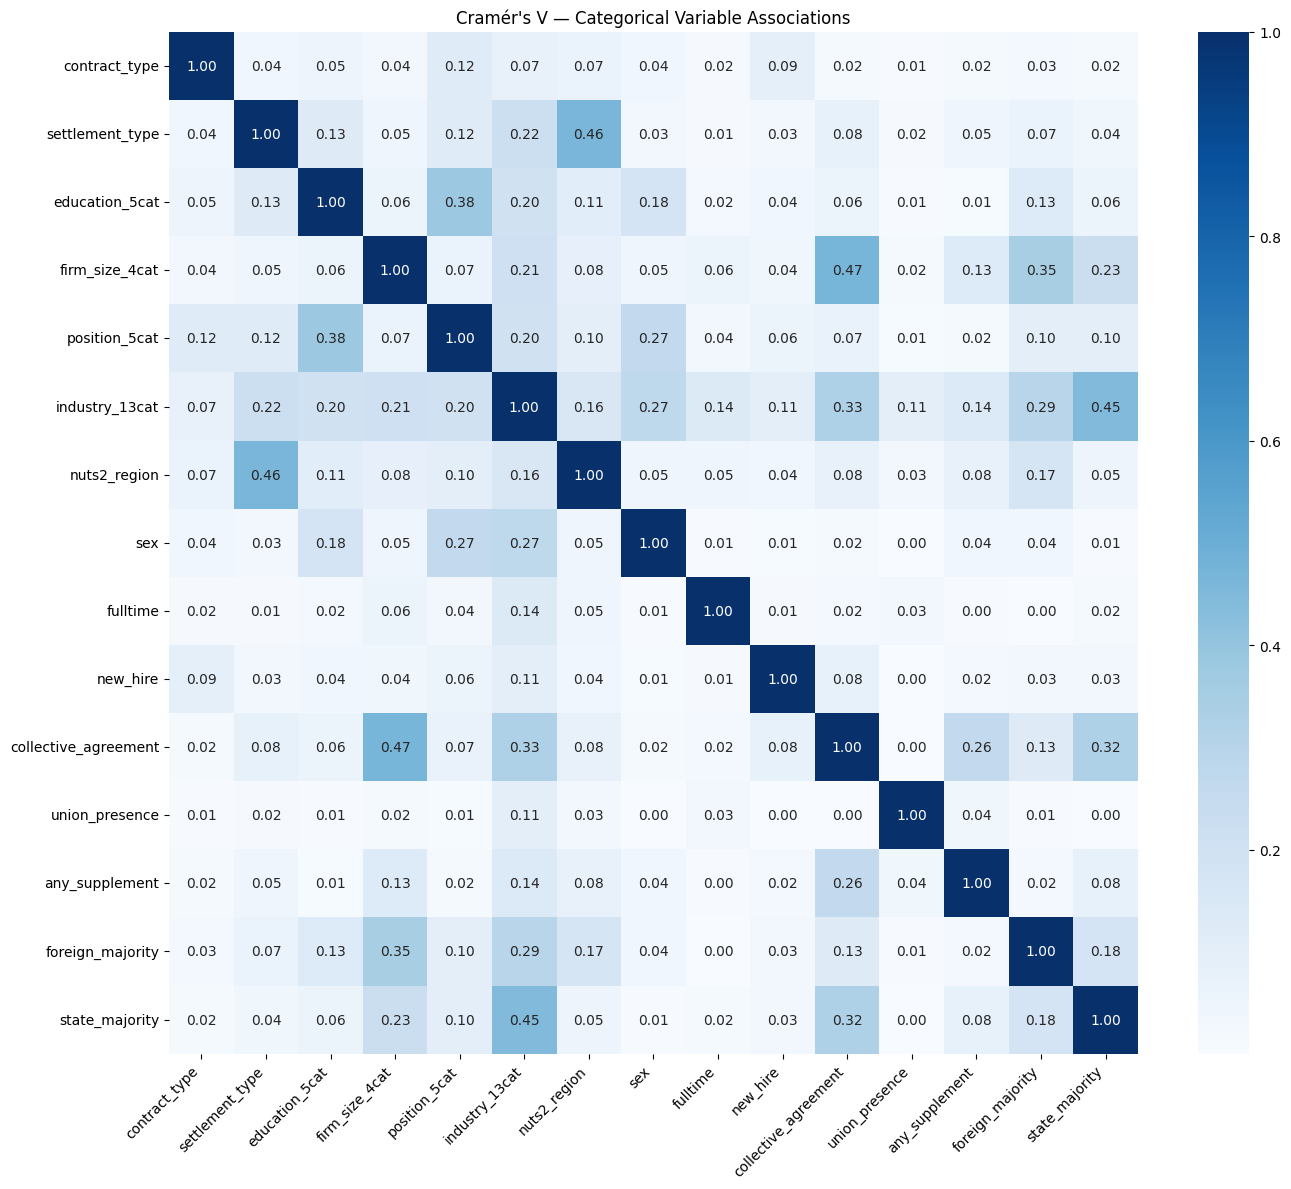

In [21]:
from scipy.stats import chi2_contingency
import itertools

cat_cols = ['contract_type', 'settlement_type', 'education_5cat', 'firm_size_4cat',
            'position_5cat', 'industry_13cat', 'nuts2_region', 'sex', 'fulltime',
            'new_hire', 'collective_agreement', 'union_presence', 'any_supplement',
            'foreign_majority', 'state_majority']

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r-1, k-1))

# Compute Cramer's V for all pairs
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1, col2 in itertools.combinations(cat_cols, 2):
    v = cramers_v(df[col1].dropna(), df[col2].dropna())
    cramers_matrix.loc[col1, col2] = v
    cramers_matrix.loc[col2, col1] = v

for col in cat_cols:
    cramers_matrix.loc[col, col] = 1.0

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=cat_cols, yticklabels=cat_cols)
plt.title("Cramér's V — Categorical Variable Associations")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Cramér's V - Categorical Variable Associations

Pearson correlation is not defined for categorical variables. We therefore compute 
Cramér's V for all pairwise combinations of categorical predictors, a chi-squared 
based measure of association bounded between 0 and 1, making it the natural analogue 
of correlation for nominal variables. No pair exceeds 0.47, and the vast majority of 
associations are below 0.15, indicating that multicollinearity among categorical 
predictors is not a concern.

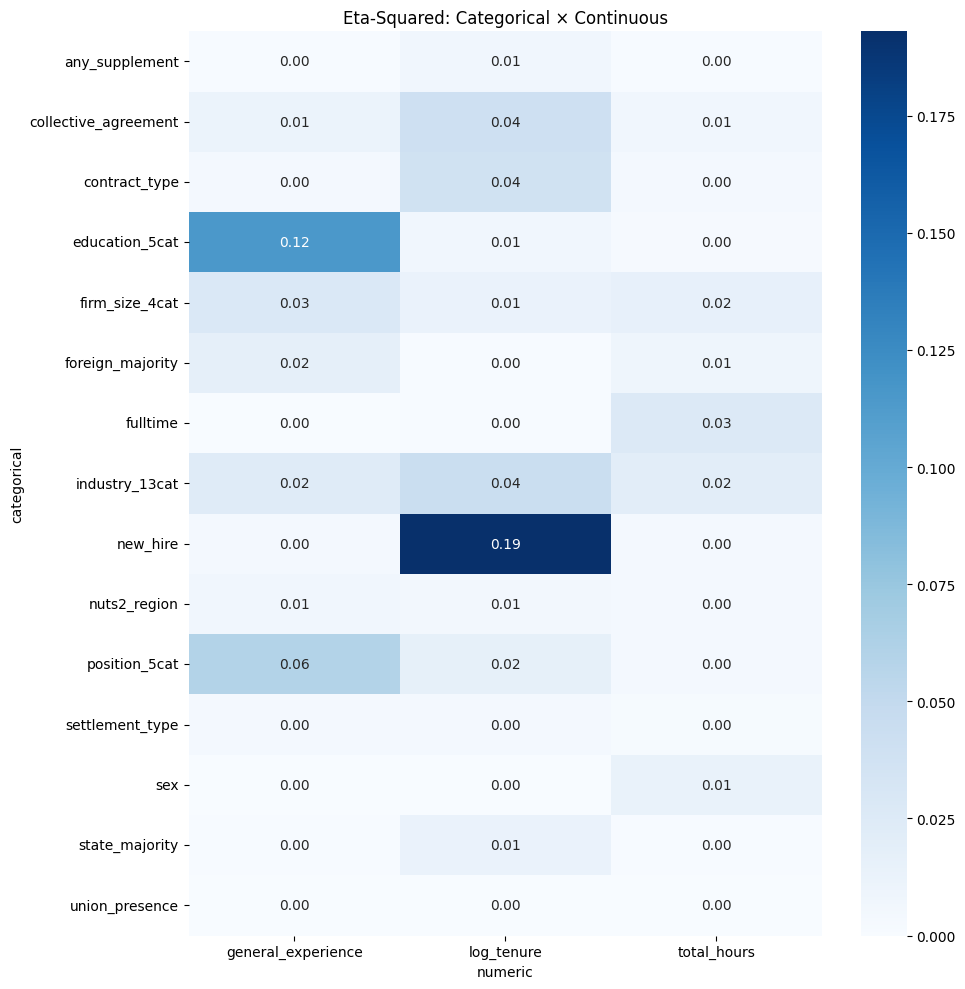

In [22]:
from scipy.stats import f_oneway

cat_cols = ['contract_type', 'settlement_type', 'education_5cat', 'firm_size_4cat',
            'position_5cat', 'industry_13cat', 'nuts2_region', 'sex', 'fulltime',
            'new_hire', 'collective_agreement', 'union_presence', 'any_supplement',
            'foreign_majority', 'state_majority']

numeric_cols = ['general_experience', 'log_tenure', 'total_hours']

def eta_squared(cat, num):
    groups = [num[cat == c].dropna() for c in cat.dropna().unique()]
    grand_mean = num.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((num - grand_mean)**2)
    return ss_between / ss_total

results = []
for c in cat_cols:
    for n in numeric_cols:
        eta2 = eta_squared(df[c], df[n].dropna())
        results.append({'categorical': c, 'numeric': n, 'eta_squared': round(eta2, 3)})

eta_df = pd.DataFrame(results).pivot(index='categorical', columns='numeric', values='eta_squared')

plt.figure(figsize=(10, 10))
sns.heatmap(eta_df, annot=True, fmt='.2f', cmap='Blues')
plt.title('Eta-Squared: Categorical × Continuous')
plt.tight_layout()
plt.show()